# AST V2 Classification: 3s / 25 Segments

This notebook trains and evaluates the second Audio Spectrogram Transformer variant using 25 random 3-second segments per track.

The model is trained on segment-level inputs. For final evaluation, segment-level predictions are aggregated to track-level predictions.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import os
import torch
import random
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from transformers import AutoProcessor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import torchaudio.transforms as T
import torch.nn as nn
import torch.nn.functional as F
from transformers import ASTModel, ASTPreTrainedModel, ASTConfig
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, f1_score
from src.config import (
    AST_AUDIO_DIR,
    AST_METADATA_CSV,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)


j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\venv\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] Die angegebene Prozedur wurde nicht gefunden'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
j:\Documents\FH\Git Repo Processing\MA_FMA_Dataprocessing\venv\Lib\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not

In [ ]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

# Paths
DATA_DIR = str(AST_AUDIO_DIR)
CSV_FILE = str(AST_METADATA_CSV)
MODEL = "MIT/ast-finetuned-audioset-16-16-0.442"
MODEL_NAME = "AST_V2_3s_25"

# Training
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 1e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
UNFREEZE_EPOCH = 3          # Epoch at which we unfreeze last 2 transformer layers
NUM_UNFROZEN_LAYERS = 6     # Number of transformer layers to unfreeze at UNFREEZE_EPOCH
ACCUMULATION_STEPS = 4      # Gradient accumulation steps
SEGMENT_LENGTH_SECONDS = 3  # Length of each randomly sampled audio segment in seconds
N_RANDOM_SEGMENTS = 25      # Number of random 3-second segments extracted per track

# Audio
MAX_AUDIO_LENGTH = 30   # Max audio length in seconds
SAMPLING_RATE = 16000   # Target sampling rate

# Filtering
TOP_K_GENRES = 8  # Only keep top K frequent genres (None = all)
EXCLUDE_GENRES = ['International', 'Instrumental', 'Experimental', 'Spoken', 'Country']  # List of genres to exclude
SAMPLES_PER_GENRE = 533  # Max number of samples per genre (None = all)

# Split ratios
VAL_SPLIT_RATIO = 0.1
TEST_SPLIT_RATIO = 0.1

# Random seeds for reproducibility
SEED = RANDOM_STATE
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE=="cuda":
    torch.cuda.manual_seed_all(SEED)


In [3]:
# ----------- LOAD CSV AND FILTER EXISTING FILES ----------- #
df = pd.read_csv(CSV_FILE, dtype={'track_id': str, 'track_genre_top': str})

# Ensure track_id always has 6 digits
df['filename'] = df['track_id'].str.zfill(6) + ".wav"

# Keep only files that exist on disk
existing_files = set(os.listdir(DATA_DIR))
df_filtered = df[df['filename'].isin(existing_files)].reset_index(drop=True)

print(f"Files in CSV: {len(df)}")
print(f"Files found on disk: {len(df_filtered)}")


# ----------- EXCLUDE GENRES AND SELECT TOP K ----------- #

# Remove unwanted genres
if EXCLUDE_GENRES:
    df_filtered = df_filtered[~df_filtered['track_genre_top'].isin(EXCLUDE_GENRES)]
    print(f"Excluded genres: {EXCLUDE_GENRES}")
    print(f"Remaining files: {len(df_filtered)}")

# Select top K most frequent genres
if TOP_K_GENRES is not None:

    genre_counts = df_filtered['track_genre_top'].value_counts()

    top_genres = genre_counts.head(TOP_K_GENRES).index.tolist()

    df_filtered = df_filtered[df_filtered['track_genre_top'].isin(top_genres)]

    print(f"\n--- Filtering Top {TOP_K_GENRES} Genres ---")
    print(f"Remaining genres: {top_genres}")
    print(f"Files after filter: {len(df_filtered)}")


# ----------- OPTIONAL: REDUCE DATASET SIZE ----------- #
#df_filtered = reduce_dataset(df_filtered, REDUCTION_FACTOR)


# ----------- BALANCING AND DATA SPLIT ----------- #

train_val_rows, test_rows = [], []
train_rows, val_rows = [], []

grouped = df_filtered.groupby("track_genre_top")

print("\n--- Balancing & Splitting ---")

for genre, group in grouped:

    n_available = len(group)

    # Limit samples per genre if configured
    if SAMPLES_PER_GENRE is not None and n_available > SAMPLES_PER_GENRE:
        group_subset = group.sample(n=SAMPLES_PER_GENRE, random_state=42)
        print(f"Genre '{genre}': reduced to {SAMPLES_PER_GENRE}")
    else:
        group_subset = group
        print(f"Genre '{genre}': using {n_available} samples")

    # Split test set
    test_size_n = max(1, int(len(group_subset) * TEST_SPLIT_RATIO))

    train_val_group, test_group = train_test_split(
        group_subset,
        test_size=test_size_n,
        random_state=42,
        shuffle=True
    )

    test_rows.append(test_group)

    # Split validation set
    val_size_n = max(1, int(len(group_subset) * VAL_SPLIT_RATIO))

    train_group, val_group = train_test_split(
        train_val_group,
        test_size=val_size_n,
        random_state=42,
        shuffle=True
    )

    train_rows.append(train_group)
    val_rows.append(val_group)


# Combine final dataframes
train_df = pd.concat(train_rows).reset_index(drop=True)
val_df = pd.concat(val_rows).reset_index(drop=True)
test_df = pd.concat(test_rows).reset_index(drop=True)


# ----------- LABEL ENCODER ----------- #
le = LabelEncoder()
le.fit(train_df['track_genre_top'])

print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Files in CSV: 106574
Files found on disk: 103871
Excluded genres: ['International', 'Instrumental', 'Experimental', 'Spoken', 'Country']
Remaining files: 89636

--- Filtering Top 8 Genres ---
Remaining genres: ['Rock', 'Electronic', 'Hip-Hop', 'Folk', 'Pop', 'Classical', 'Jazz', 'Old-Time / Historic']
Files after filter: 33606

--- Balancing & Splitting ---
Genre 'Classical': reduced to 533
Genre 'Electronic': reduced to 533
Genre 'Folk': reduced to 533
Genre 'Hip-Hop': reduced to 533
Genre 'Jazz': reduced to 533
Genre 'Old-Time / Historic': reduced to 533
Genre 'Pop': reduced to 533
Genre 'Rock': reduced to 533
Class mapping: {'Classical': np.int64(0), 'Electronic': np.int64(1), 'Folk': np.int64(2), 'Hip-Hop': np.int64(3), 'Jazz': np.int64(4), 'Old-Time / Historic': np.int64(5), 'Pop': np.int64(6), 'Rock': np.int64(7)}


In [4]:
df_filtered.value_counts('track_genre_top')

track_genre_top
Rock                   13942
Electronic              9112
Hip-Hop                 3487
Folk                    2769
Pop                     1985
Classical               1210
Jazz                     567
Old-Time / Historic      534
Name: count, dtype: int64

In [5]:

# ---------------------------------------------------------
# EXPAND TRACKS INTO RANDOM SEGMENT SAMPLES
# ---------------------------------------------------------
# Each original track is repeated N_RANDOM_SEGMENTS times.
# The actual 3-second audio crop is selected inside the Dataset based on segment_id.
# This keeps the train/val/test split on track level, while the model is trained on segment samples.
def expand_to_random_segments(df, n_segments=N_RANDOM_SEGMENTS):
    expanded_rows = []

    for _, row in df.iterrows():
        for segment_id in range(n_segments):
            new_row = row.copy()
            new_row["segment_id"] = segment_id
            expanded_rows.append(new_row)

    return pd.DataFrame(expanded_rows).reset_index(drop=True)

# Create segment-level dataframes.
# Example: 1 track -> 25 rows -> 25 random 3-second segments.
train_segments_df = expand_to_random_segments(train_df)
val_segments_df = expand_to_random_segments(val_df)
test_segments_df = expand_to_random_segments(test_df)

print(f"Train segments: {len(train_segments_df)} ({len(train_df)} tracks × {N_RANDOM_SEGMENTS})")
print(f"Validation segments: {len(val_segments_df)} ({len(val_df)} tracks × {N_RANDOM_SEGMENTS})")
print(f"Test segments: {len(test_segments_df)} ({len(test_df)} tracks × {N_RANDOM_SEGMENTS})")


Train segments: 85400 (3416 tracks × 25)
Validation segments: 10600 (424 tracks × 25)
Test segments: 10600 (424 tracks × 25)


In [6]:
# -------------------------------
# SpecAugment: Frequency & Time Masking
# -------------------------------

# Randomly mask frequency bands (max 30 bins) and time segments (max 100 frames)
freq_masking = T.FrequencyMasking(freq_mask_param=24)
time_masking = T.TimeMasking(time_mask_param=60)

def apply_spec_augment(spec):
    if spec.dim() == 2:
        spec = spec.unsqueeze(0)
        squeeze_back = True
    else:
        squeeze_back = False

    spec = freq_masking(spec)
    spec = time_masking(spec)

    if squeeze_back:
        spec = spec.squeeze(0)
    return spec

In [7]:
class CSVDataset(Dataset):
    """
    PyTorch dataset for audio segments and labels.
    Handles loading, mono conversion, resampling, random 3-second cropping,
    and AST processor preparation.
    
    Important:
    - The dataframe is already expanded to N_RANDOM_SEGMENTS rows per track.
    - segment_id is used to draw reproducible random 3-second segments.
    - This allows segment-level training and later track-level aggregation.
    """
    def __init__(self, df, root_dir, processor, segment_length_seconds=SEGMENT_LENGTH_SECONDS, le=None, split="train"):
        # Store audio processor
        self.processor = processor

        # Length of one randomly sampled segment in seconds
        self.segment_length_seconds = segment_length_seconds

        # Root directory where audio files are stored
        self.root_dir = root_dir

        # Make a copy of the dataframe to avoid modifying the original
        self.df = df.copy().reset_index(drop=True)

        # LabelEncoder instance (used to convert string labels → integer labels)
        self.le = le

        # Dataset split name (train / val / test)
        self.split = split

        # Convert genre names to integer labels
        self.df['label'] = self.le.transform(self.df['track_genre_top'])

    def __len__(self):
        # Return total number of segment samples in the dataset
        return len(self.df)

    def _get_deterministic_start(self, num_samples, target_len, track_id, segment_id):
        """
        Select a reproducible random start position for one segment.
        This keeps validation and test evaluation stable across runs.
        """
        if num_samples <= target_len:
            return 0

        # Build a deterministic seed from track_id, segment_id and global SEED
        local_seed = (int(str(track_id)) * 1009 + int(segment_id) * 9176 + SEED) % (2**32 - 1)
        rng = np.random.RandomState(local_seed)
        return int(rng.randint(0, num_samples - target_len + 1))

    def __getitem__(self, idx):
        # Get one segment sample by index
        row = self.df.iloc[idx]

        # Construct full file path
        file_path = os.path.join(self.root_dir, str(row['filename']))

        # Get integer label and segment metadata
        label = int(row['label'])
        track_id = row["track_id"]
        segment_id = int(row.get("segment_id", 0))

        try:
            # Load audio file
            waveform_np, sr = sf.read(file_path, dtype="float32")

            # If audio is mono, add channel dimension
            if waveform_np.ndim == 1:
                waveform_np = np.expand_dims(waveform_np, axis=0)

            # If shape is (samples, channels), transpose to (channels, samples)
            elif waveform_np.ndim == 2 and waveform_np.shape[0] > waveform_np.shape[1]:
                waveform_np = waveform_np.T

        except Exception as e:
            # If loading fails, use zero tensor as fallback
            print(f"Error loading {file_path}: {e}")
            waveform_np = np.zeros((1, SAMPLING_RATE * self.segment_length_seconds), dtype="float32")
            sr = SAMPLING_RATE

        # Convert NumPy array to PyTorch tensor
        waveform = torch.tensor(waveform_np, dtype=torch.float32)

        # Resample to the target sampling rate if needed
        if sr != SAMPLING_RATE:
            waveform = torch.nn.functional.interpolate(
                waveform.unsqueeze(0),
                size=int(SAMPLING_RATE * waveform.shape[1] / sr),
                mode="linear",
                align_corners=False
            ).squeeze(0)

        # Convert stereo to mono by averaging channels
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Ensure fixed segment length: 3 seconds
        target_len = SAMPLING_RATE * self.segment_length_seconds

        if waveform.shape[1] > target_len:
            # Select one reproducible random 3-second crop for this segment_id
            start = self._get_deterministic_start(
                num_samples=waveform.shape[1],
                target_len=target_len,
                track_id=track_id,
                segment_id=segment_id
            )
            waveform = waveform[:, start:start + target_len]

        elif waveform.shape[1] < target_len:
            # Pad short files to the required 3-second length
            waveform = F.pad(waveform, (0, target_len - waveform.shape[1]))

        # Convert tensor back to NumPy for the AST processor
        waveform_final_np = waveform.squeeze().numpy()

        # Extract model inputs using the feature processor
        inputs = self.processor(
            waveform_final_np,
            sampling_rate=SAMPLING_RATE,
            return_tensors="pt"
        )

        input_values = inputs["input_values"].squeeze(0)

        # Apply SpecAugment only to training samples
        if self.split == "train":
            input_values = apply_spec_augment(input_values)

        return input_values, torch.tensor(label, dtype=torch.long), str(track_id), segment_id


In [8]:
# ============================================================
# CUSTOM AST CLASSIFIER
# ============================================================

class CustomASTClassifier(ASTPreTrainedModel):
    """
    Custom audio classifier based on AST (Audio Spectrogram Transformer)
    Includes a trainable head with residual connection on top of frozen or unfrozen AST backbone.
    """
    def __init__(self, config, freeze_backbone=False):
        super().__init__(config)
        self.num_labels = config.num_labels

        # Load AST backbone
        self.audio_spectrogram_transformer = ASTModel(config)

        # Optionally freeze backbone weights
        if freeze_backbone:
            for param in self.audio_spectrogram_transformer.parameters():
                param.requires_grad = False

        # CLASSIFIER HEAD
        # First linear layer
        self.head_linear1 = nn.Linear(config.hidden_size, 512)
        self.head_ln1 = nn.LayerNorm(512)
        self.dropout1 = nn.Dropout(0.4)

        # Second linear layer (residual)
        self.head_linear2 = nn.Linear(512, 512)  # Keep same dimension for residual
        self.head_ln2 = nn.LayerNorm(512)
        self.dropout2 = nn.Dropout(0.3)

        # Output layer
        self.classifier_out = nn.Linear(512, config.num_labels)

        # Initialize weights
        self.init_weights()

    def forward(self, input_values, labels=None, **kwargs):
        """
        Forward pass
        input_values: Tensor of shape [batch, time, freq]
        labels: optional tensor for computing loss
        """
        # Get AST outputs
        outputs = self.audio_spectrogram_transformer(input_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # Take [CLS] token output

        # Head Layer
        x = self.head_linear1(cls_output)
        x = self.head_ln1(x)
        x = F.gelu(x)
        x = self.dropout1(x)

        res = x  # Save residual

        x = self.head_linear2(x)
        x = self.head_ln2(x)
        x = F.gelu(x)
        x = self.dropout2(x)

        x = x + res  # Add residual connection

        logits = self.classifier_out(x)

        # Compute loss if labels provided
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        # Return dictionary with loss & logits if loss is computed
        return {"loss": loss, "logits": logits} if loss is not None else logits


# ============================================================
# INITIALIZATION
# ============================================================

# Device selection
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load AST configuration
config = ASTConfig.from_pretrained(
    "MIT/ast-finetuned-audioset-16-16-0.442", 
    num_labels=8  # Adjust to number of classes
)

# Initialize model with optional freezing of backbone
model = CustomASTClassifier.from_pretrained(
    "MIT/ast-finetuned-audioset-16-16-0.442",
    config=config,
    freeze_backbone=False  # True if only head should be trained
)

# Move model to device
model.to(DEVICE)

print("Model loaded and ready on device:", DEVICE)

Some weights of CustomASTClassifier were not initialized from the model checkpoint at MIT/ast-finetuned-audioset-16-16-0.442 and are newly initialized: ['classifier_out.bias', 'classifier_out.weight', 'head_linear1.bias', 'head_linear1.weight', 'head_linear2.bias', 'head_linear2.weight', 'head_ln1.bias', 'head_ln1.weight', 'head_ln2.bias', 'head_ln2.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded and ready on device: cuda


In [9]:
def mixup_data(x, y, alpha=0.2):
    '''Returns mixed inputs, pairs of targets, and the mixing coefficient lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x.size()[0]
    # Generate random indices to shuffle the batch
    index = torch.randperm(batch_size).to(x.device)

    # Linear combination of the original and shuffled inputs
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for inputs, labels, _, _ in tqdm(loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Apply Mixup augmentation
        inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.2)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        
        # Calculate loss as a weighted sum of the two label components
        loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    return total_loss / len(loader)


In [10]:
# ============================================================
# PROCESSOR & MODEL SETUP
# ============================================================

# Load the processor for AST model
processor = AutoProcessor.from_pretrained(MODEL)

# ============================================================
# FREEZE BACKBONE & ENABLE CLASSIFIER
# ============================================================

# Freeze entire AST backbone
for param in model.audio_spectrogram_transformer.parameters():
    param.requires_grad = False

# Define head layers (classifier layers) that remain trainable
head_layers = [
    model.head_linear1,
    model.head_ln1,
    model.head_linear2,
    model.head_ln2,
    model.classifier_out
]

# Enable training for the head layers
for layer in head_layers:
    for param in layer.parameters():
        param.requires_grad = True


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [11]:
# ============================================================
# DATASET & DATALOADER
# ============================================================

# Create train, validation, and test datasets from the segment-level dataframes.
# Each original track contributes N_RANDOM_SEGMENTS randomly sampled 3-second segments.
train_dataset = CSVDataset(train_segments_df, DATA_DIR, processor, segment_length_seconds=SEGMENT_LENGTH_SECONDS, le=le, split="train")
val_dataset   = CSVDataset(val_segments_df,   DATA_DIR, processor, segment_length_seconds=SEGMENT_LENGTH_SECONDS, le=le, split="val")
test_dataset  = CSVDataset(test_segments_df,  DATA_DIR, processor, segment_length_seconds=SEGMENT_LENGTH_SECONDS, le=le, split="test")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, drop_last=False)  # Validation, shuffle not needed
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)   # Test, no shuffle


In [ ]:
# ============================================================
# STORAGE FOR VISUALIZATION
# ============================================================
train_losses = []
val_losses = []
val_accuracies = []

# ============================================================
# TRAINING PARAMETERS
# ============================================================

# Scheduler & optimizer initialization
warmup_steps = int(0.1 * len(train_loader) * EPOCHS)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=len(train_loader) * EPOCHS
)

# Loss function
criterion = nn.CrossEntropyLoss()


In [13]:
# ============================================================
# TRAINING LOOP
# ============================================================

# Define loss function with label smoothing
loss_fct = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

for epoch in range(EPOCHS):
    
    # UNFREEZE LOGIC: Transition from training only the head to fine-tuning the backbone
    if epoch == UNFREEZE_EPOCH:
        for layer in model.audio_spectrogram_transformer.encoder.layer[-NUM_UNFROZEN_LAYERS:]:
            for param in layer.parameters():
                param.requires_grad = True

        optimizer = torch.optim.AdamW([
            {'params': model.audio_spectrogram_transformer.encoder.layer[-NUM_UNFROZEN_LAYERS:].parameters(), 'lr': 5e-6},
            {'params': model.audio_spectrogram_transformer.embeddings.parameters(), 'lr': 2e-6},
            {'params': model.head_linear1.parameters(), 'lr': LEARNING_RATE},
            {'params': model.head_ln1.parameters(), 'lr': LEARNING_RATE},
            {'params': model.head_linear2.parameters(), 'lr': LEARNING_RATE},
            {'params': model.head_ln2.parameters(), 'lr': LEARNING_RATE},
            {'params': model.classifier_out.parameters(), 'lr': LEARNING_RATE},
        ], weight_decay=0.01)

        # Re-calculate scheduler for the remaining steps
        remaining_steps = (len(train_loader) // ACCUMULATION_STEPS) * (EPOCHS - epoch)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, 
            num_warmup_steps=int(0.1 * remaining_steps), 
            num_training_steps=remaining_steps
        )

    # TRAINING PHASE
    model.train()
    total_train_loss = 0
    optimizer.zero_grad() # Initialize gradients

    for i, (inputs, labels, track_ids, segment_ids) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch}")):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # AST expects [Batch, Time, Freq]; remove extra channel dimension if present
        if inputs.dim() == 4:
            inputs = inputs.squeeze(1)

        # Apply Mixup Augmentation
        # (This blends two images and their labels to improve generalization)
        inputs, labels_a, labels_b, lam = mixup_data(inputs, labels, alpha=0.2)
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate Mixup loss (weighted sum of two labels)
        loss = lam * loss_fct(outputs, labels_a) + (1 - lam) * loss_fct(outputs, labels_b)
        
        # Scale loss for gradient accumulation
        loss = loss / ACCUMULATION_STEPS
        loss.backward()

        # Update weights every N steps (Gradient Accumulation)
        if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        total_train_loss += loss.item() * ACCUMULATION_STEPS

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Epoch {epoch} - Average Training Loss: {avg_train_loss:.4f}")


Epoch 0: 100%|██████████| 2668/2668 [1:47:58<00:00,  2.43s/it]  


Epoch 0 - Average Training Loss: 2.1506


Epoch 1: 100%|██████████| 2668/2668 [1:41:59<00:00,  2.29s/it]  


Epoch 1 - Average Training Loss: 2.0192


Epoch 2: 100%|██████████| 2668/2668 [1:51:29<00:00,  2.51s/it]  


...

Epoch 57 - Average Training Loss: 0.7701


Epoch 58: 100%|██████████| 2668/2668 [1:42:15<00:00,  2.30s/it]


Epoch 58 - Average Training Loss: 0.7777


Epoch 59: 100%|██████████| 2668/2668 [1:50:06<00:00,  2.48s/it]

Epoch 59 - Average Training Loss: 0.7754


In [14]:
# ---------------------------------------------------------
# VALIDATION EVALUATION
# ---------------------------------------------------------
model.eval()
total_val_loss = 0
correct_predictions = 0
total_samples = 0

with torch.no_grad():
    for batch in val_loader:
        inputs, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)

        if inputs.dim() == 4:
            inputs = inputs.squeeze(1)

        outputs = model(inputs, labels=labels)
        val_loss = outputs["loss"]
        logits = outputs["logits"]

        total_val_loss += val_loss.item()
        preds = torch.argmax(logits, dim=1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)

avg_val_loss = total_val_loss / len(val_loader)
val_accuracy = correct_predictions / total_samples

# Store metrics
train_losses.append(avg_train_loss)
val_losses.append(avg_val_loss)
val_accuracies.append(val_accuracy)

print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")


Epoch 60/60 | Train Loss: 0.7754 | Val Loss: 1.2506 | Val Acc: 0.7236


In [15]:
def evaluate_model(model, loader, set_name):
    # Print which dataset is currently being evaluated (e.g., Train / Validation / Test)
    print(f"\n--- {set_name} Segment-Level Evaluation ---")
    
    # Set model to evaluation mode (disables dropout, batchnorm updates, etc.)
    model.eval()

    # Lists to collect predictions, true labels, probabilities and metadata
    all_preds = []
    all_labels = []
    all_probs = []
    all_track_ids = []
    all_segment_ids = []

    # Disable gradient computation for faster and memory-efficient inference
    with torch.no_grad():
        for inputs, labels, track_ids, segment_ids in loader:
            # Move data to the selected device (CPU or GPU)
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)

            # AST expects [Batch, Time, Freq]; remove extra channel dimension if present
            if inputs.dim() == 4:
                inputs = inputs.squeeze(1)

            # Forward pass through the model
            outputs = model(inputs)
            logits = outputs["logits"] if isinstance(outputs, dict) else outputs

            # Convert logits to class probabilities and predicted class indices
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            # Store predictions, probabilities, true labels and metadata for later evaluation
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_track_ids.extend(track_ids)
            all_segment_ids.extend(segment_ids.cpu().numpy() if torch.is_tensor(segment_ids) else segment_ids)

    # Convert lists to arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Print overall segment-level metrics
    print("Accuracy:", accuracy_score(all_labels, all_preds))
    print("Macro-F1:", f1_score(all_labels, all_preds, average="macro"))

    # Print detailed classification metrics (precision, recall, F1-score per class)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=le.classes_))

    # Create confusion matrix visualization
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix as a heatmap
    sns.heatmap(
        cm,
        annot=True,              # Show numbers in cells
        fmt="d",                 # Integer format
        cmap="Blues",            # Color map
        xticklabels=le.classes_, # Predicted class labels
        yticklabels=le.classes_  # True class labels
    )

    # Axis labels
    plt.xlabel(f"Predicted Label ({set_name}, Segment-Level)")
    plt.ylabel(f"True Label ({set_name}, Segment-Level)")

    # Plot title
    plt.title(f"Confusion Matrix ({set_name}, Segment-Level)")

    # Adjust layout to prevent label overlap
    plt.tight_layout()
    plt.show()

    # Create dataframe for optional track-level aggregation
    segment_analysis_df = pd.DataFrame({
        "track_id": all_track_ids,
        "segment_id": all_segment_ids,
        "true_label": all_labels,
        "predicted_label": all_preds,
        "true_genre": le.inverse_transform(all_labels),
        "predicted_genre": le.inverse_transform(all_preds)
    })

    # Add one probability column per class for mean-probability aggregation
    for i, class_name in enumerate(le.classes_):
        segment_analysis_df[f"prob_{class_name}"] = all_probs[:, i]

    return segment_analysis_df



--- Validation Segment-Level Evaluation ---
Accuracy: 0.7235849056603774
Macro-F1: 0.7222986646092533
Classification Report:
                     precision    recall  f1-score   support

          Classical       0.91      0.91      0.91      1325
         Electronic       0.62      0.63      0.63      1325
               Folk       0.70      0.56      0.62      1325
            Hip-Hop       0.76      0.76      0.76      1325
               Jazz       0.73      0.83      0.77      1325
Old-Time / Historic       0.97      0.99      0.98      1325
                Pop       0.43      0.45      0.44      1325
               Rock       0.67      0.66      0.67      1325

           accuracy                           0.72     10600
          macro avg       0.72      0.72      0.72     10600
       weighted avg       0.72      0.72      0.72     10600



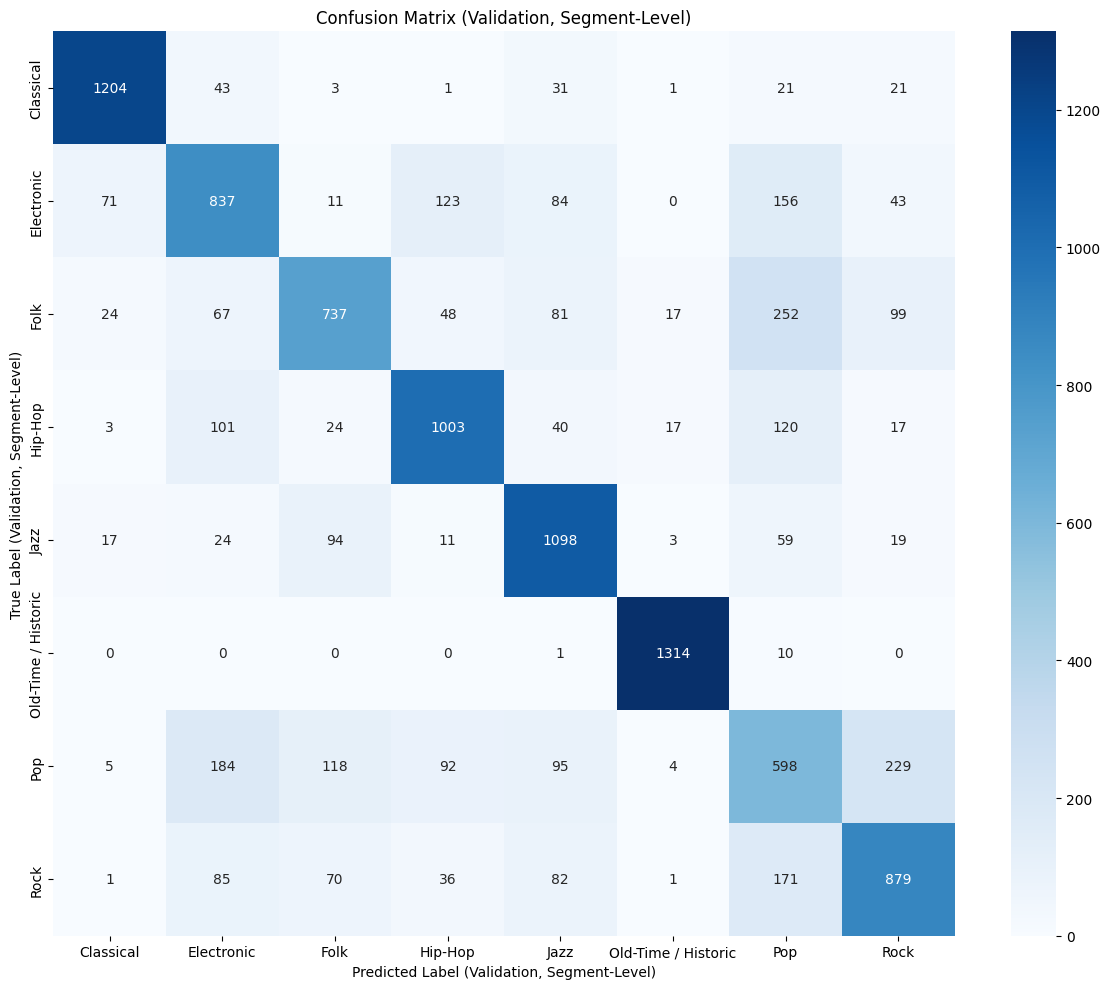


--- Test Segment-Level Evaluation ---
Accuracy: 0.7481132075471698
Macro-F1: 0.746267035289313
Classification Report:
                     precision    recall  f1-score   support

          Classical       0.93      0.89      0.91      1325
         Electronic       0.64      0.55      0.59      1325
               Folk       0.69      0.73      0.71      1325
            Hip-Hop       0.79      0.81      0.80      1325
               Jazz       0.75      0.77      0.76      1325
Old-Time / Historic       0.98      1.00      0.99      1325
                Pop       0.47      0.46      0.47      1325
               Rock       0.72      0.78      0.75      1325

           accuracy                           0.75     10600
          macro avg       0.75      0.75      0.75     10600
       weighted avg       0.75      0.75      0.75     10600



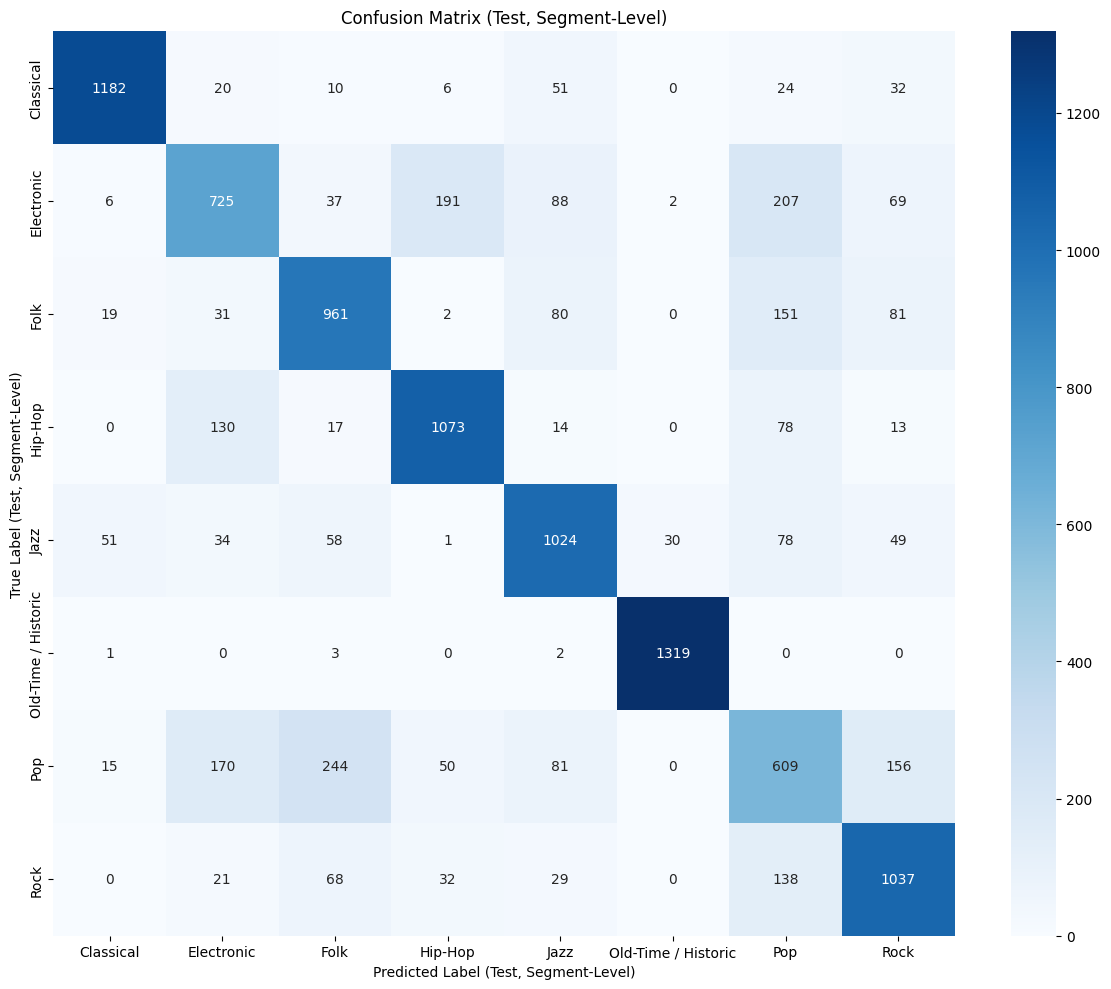

In [ ]:
# Evaluate the model on the validation set
# Prints segment-level classification metrics and plots a confusion matrix
val_segment_analysis_df = evaluate_model(model, val_loader, "Validation")

# Evaluate the model on the test set
# Same metrics and visualization but on unseen test data
test_segment_analysis_df = evaluate_model(model, test_loader, "Test")


Number of misclassified test segments: 2670
    track_id  segment_id  true_label  predicted_label true_genre  \
137    11423          12           0                4  Classical   
200    51939           0           0                3  Classical   
201    51939           1           0                6  Classical   
202    51939           2           0                3  Classical   
203    51939           3           0                2  Classical   

    predicted_genre  prob_Classical  prob_Electronic  prob_Folk  prob_Hip-Hop  \
137            Jazz        0.273356         0.012854   0.019682      0.020971   
200         Hip-Hop        0.007798         0.005767   0.011449      0.928060   
201             Pop        0.014748         0.013551   0.029817      0.044082   
202         Hip-Hop        0.031919         0.025066   0.285167      0.333706   
203            Folk        0.078023         0.020634   0.564840      0.227907   

     prob_Jazz  prob_Old-Time / Historic  prob_Pop  prob_Roc

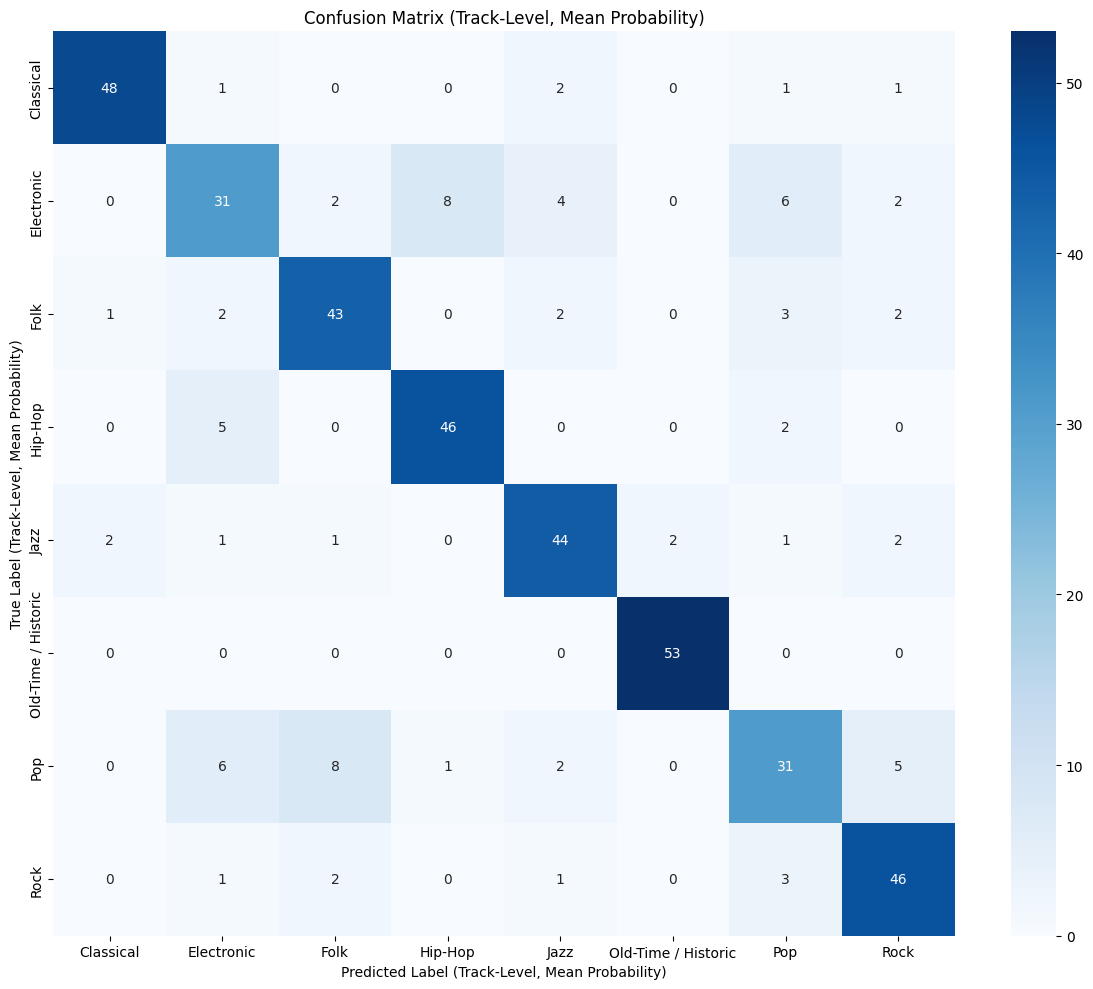


--- TRACK-LEVEL TEST REPORT: MAJORITY VOTING ---
Accuracy: 0.8018867924528302
Macro-F1: 0.7985974349590759

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.94      0.91      0.92        53
         Electronic       0.64      0.55      0.59        53
               Folk       0.76      0.79      0.78        53
            Hip-Hop       0.84      0.89      0.86        53
               Jazz       0.82      0.85      0.83        53
Old-Time / Historic       0.96      1.00      0.98        53
                Pop       0.60      0.57      0.58        53
               Rock       0.81      0.87      0.84        53

           accuracy                           0.80       424
          macro avg       0.80      0.80      0.80       424
       weighted avg       0.80      0.80      0.80       424



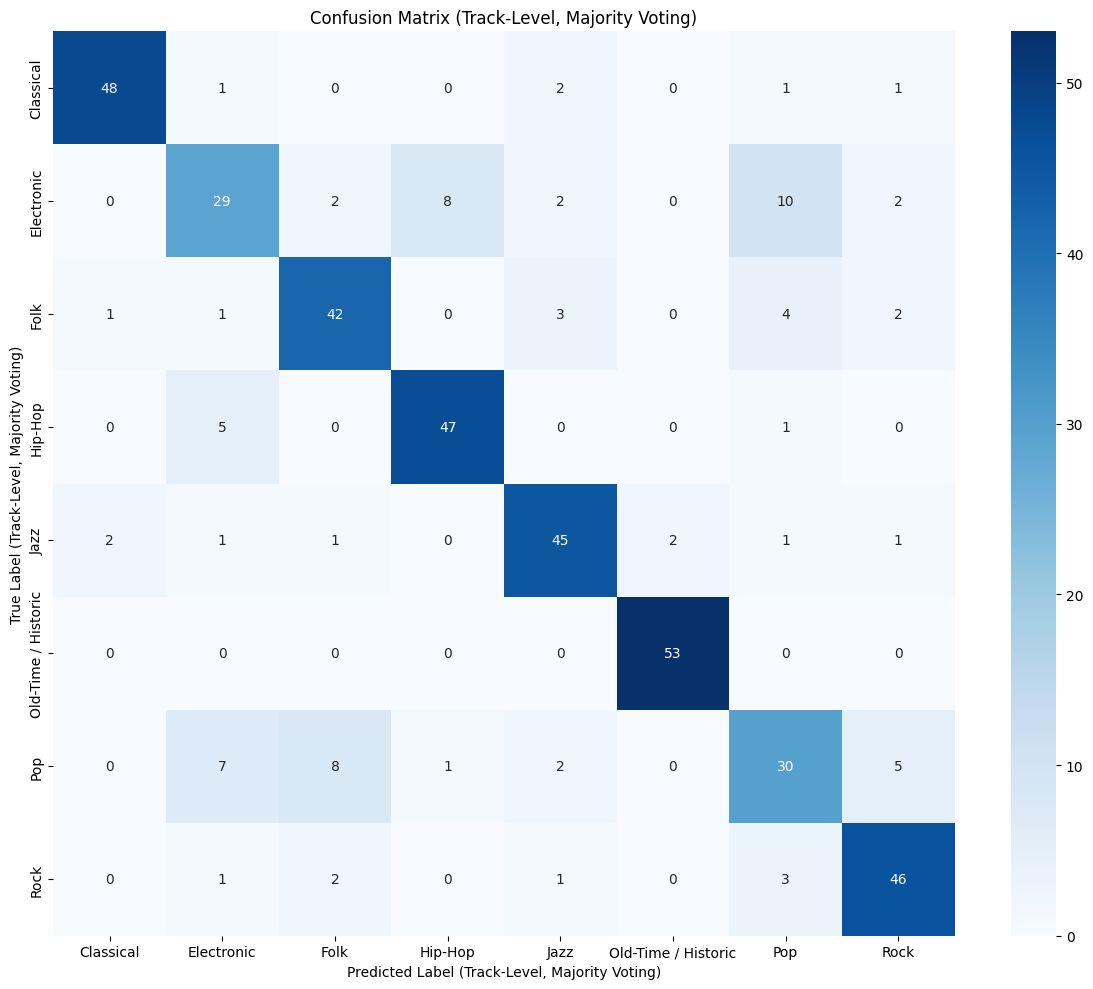

In [ ]:
# ============================================================
# SEGMENT-LEVEL AND TRACK-LEVEL ERROR ANALYSIS
# ============================================================

# The model predicts one label per 3-second segment.
# For the final music-track evaluation, all segment predictions of the same track
# are aggregated into one track-level prediction.

# ---------------------------------------------------------
# SAVE MISCLASSIFIED TEST SEGMENTS
# ---------------------------------------------------------
misclassified_segments = test_segment_analysis_df[
    test_segment_analysis_df["true_label"] != test_segment_analysis_df["predicted_label"]
].copy()

print(f"Number of misclassified test segments: {len(misclassified_segments)}")
print(misclassified_segments.head())

# Save segment-level misclassifications for further analysis
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

misclassified_segments.to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_segments.csv",
    index=False
)

# ---------------------------------------------------------
# TRACK-LEVEL EVALUATION: MEAN PROBABILITY
# ---------------------------------------------------------
# For each track, average the predicted class probabilities over all 25 segments.
# The class with the highest mean probability becomes the final track prediction.
prob_cols = [f"prob_{class_name}" for class_name in le.classes_]

track_probs = (
    test_segment_analysis_df
    .groupby("track_id")[prob_cols]
    .mean()
    .reset_index()
)

track_true = (
    test_segment_analysis_df
    .groupby("track_id")[["true_label", "true_genre"]]
    .first()
    .reset_index()
)

track_eval_mean_prob = track_probs.merge(track_true, on="track_id")
track_eval_mean_prob["predicted_label"] = track_eval_mean_prob[prob_cols].values.argmax(axis=1)
track_eval_mean_prob["predicted_genre"] = le.inverse_transform(track_eval_mean_prob["predicted_label"])

print("\n--- TRACK-LEVEL TEST REPORT: MEAN PROBABILITY ---")
print("Accuracy:", accuracy_score(track_eval_mean_prob["true_label"], track_eval_mean_prob["predicted_label"]))
print("Macro-F1:", f1_score(track_eval_mean_prob["true_label"], track_eval_mean_prob["predicted_label"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_eval_mean_prob["true_label"],
    track_eval_mean_prob["predicted_label"],
    target_names=le.classes_
))

plt.figure(figsize=(12, 10))
cm_mean_prob = confusion_matrix(track_eval_mean_prob["true_label"], track_eval_mean_prob["predicted_label"])
sns.heatmap(
    cm_mean_prob,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label (Track-Level, Mean Probability)")
plt.ylabel("True Label (Track-Level, Mean Probability)")
plt.title("Confusion Matrix (Track-Level, Mean Probability)")
plt.tight_layout()
plt.show()

# Save all track-level predictions and the corresponding misclassifications
track_eval_mean_prob.to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_mean_probability.csv",
    index=False
)

misclassified_tracks_mean_prob = track_eval_mean_prob[
    track_eval_mean_prob["true_label"] != track_eval_mean_prob["predicted_label"]
].copy()

misclassified_tracks_mean_prob[["track_id", "true_genre", "predicted_genre"]].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_mean_probability.csv",
    index=False
)

# ---------------------------------------------------------
# TRACK-LEVEL EVALUATION: MAJORITY VOTING
# ---------------------------------------------------------
# For each track, select the genre predicted most often across the 25 segments.
track_eval_majority = (
    test_segment_analysis_df
    .groupby("track_id")
    .agg(
        true_label=("true_label", "first"),
        true_genre=("true_genre", "first"),
        predicted_label=("predicted_label", lambda x: x.value_counts().idxmax())
    )
    .reset_index()
)

track_eval_majority["predicted_genre"] = le.inverse_transform(track_eval_majority["predicted_label"])

print("\n--- TRACK-LEVEL TEST REPORT: MAJORITY VOTING ---")
print("Accuracy:", accuracy_score(track_eval_majority["true_label"], track_eval_majority["predicted_label"]))
print("Macro-F1:", f1_score(track_eval_majority["true_label"], track_eval_majority["predicted_label"], average="macro"))
print("\nClassification Report:")
print(classification_report(
    track_eval_majority["true_label"],
    track_eval_majority["predicted_label"],
    target_names=le.classes_
))

plt.figure(figsize=(12, 10))
cm_majority = confusion_matrix(track_eval_majority["true_label"], track_eval_majority["predicted_label"])
sns.heatmap(
    cm_majority,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted Label (Track-Level, Majority Voting)")
plt.ylabel("True Label (Track-Level, Majority Voting)")
plt.title("Confusion Matrix (Track-Level, Majority Voting)")
plt.tight_layout()
plt.show()

# Save all track-level predictions and the corresponding misclassifications
track_eval_majority.to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_majority_voting.csv",
    index=False
)

misclassified_tracks_majority = track_eval_majority[
    track_eval_majority["true_label"] != track_eval_majority["predicted_label"]
].copy()

misclassified_tracks_majority[["track_id", "true_genre", "predicted_genre"]].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_majority_voting.csv",
    index=False
)